### [Dimensionality Reduction with PCA in Finance](https://medium.com/@simplifiedzone/10a221092f16)

> Machine Learning for Quants (Part 6)

In [1]:
# Install required packages (only if missing)
# In Colab, this should take ~30 seconds

import subprocess
import sys

def install_if_missing(package, import_name=None):
    """Install package if not already available."""
    import_name = import_name or package.split('[')[0]  # handle extras like langchain[google]
    try:
        __import__(import_name.replace('-', '_'))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("pandas-datareader", "pandas_datareader")
print("✓ All packages ready!")

✓ All packages ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Define the exact FRED ticker symbols for various maturities
tickers = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
labels = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

# Fetch 10 years of data
start_date = datetime.datetime(2016, 1, 1)
end_date = datetime.datetime(2026, 1, 1)

print("Fetching data from FRED...")
yield_data = web.DataReader(tickers, 'fred', start_date, end_date)

# Rename columns for readability and drop any days with missing data (like holidays)
yield_data.columns = labels
yield_data.dropna(inplace=True)

print(f"Data Loaded: {yield_data.shape[0]} trading days, {yield_data.shape[1]} maturities.")
display(yield_data.head())

Fetching data from FRED...
Data Loaded: 2499 trading days, 11 maturities.


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
DATE,,,,,,,,,,,
2016-01-04,0.17,0.22,0.49,0.61,1.02,1.31,1.73,2.06,2.24,2.64,2.98
2016-01-05,0.20,0.20,0.49,0.68,1.04,1.32,1.73,2.06,2.25,2.67,3.01
2016-01-06,0.21,0.21,0.47,0.67,0.99,1.26,1.65,1.98,2.18,2.59,2.94
2016-01-07,0.20,0.20,0.46,0.66,0.96,1.22,1.61,1.94,2.16,2.56,2.92
2016-01-08,0.20,0.20,0.45,0.64,0.94,1.20,1.57,1.91,2.13,2.55,2.91


In [4]:
# 1. Calculate daily changes in yields
yield_changes = yield_data.diff().dropna()

# 2. Standardize the data
# PCA is highly sensitive to the scale of features. We must center the data (mean=0, variance=1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(yield_changes)

# Convert back to DataFrame for easier plotting later
X_scaled_df = pd.DataFrame(X_scaled, columns=labels, index=yield_changes.index)

print("First 5 rows of scaled yield changes:")
display(X_scaled_df.head())

First 5 rows of scaled yield changes:


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
DATE,,,,,,,,,,,
2016-01-05,0.565641,-0.689633,-0.040006,1.652808,0.355465,0.164998,-0.014274,-0.013405,0.172634,0.565584,0.574950
2016-01-06,0.169684,0.277997,-0.684741,-0.267636,-0.952819,-1.103761,-1.440529,-1.438320,-1.324727,-1.569479,-1.390328
2016-01-07,-0.226272,-0.367090,-0.362373,-0.267636,-0.579024,-0.741258,-0.727401,-0.725862,-0.388876,-0.598996,-0.407689
2016-01-08,-0.028294,-0.044547,-0.362373,-0.507691,-0.392126,-0.378756,-0.727401,-0.547748,-0.576046,-0.210802,-0.211161
2016-01-11,-0.226272,0.277997,0.927097,-0.267636,-0.018331,-0.016253,0.164008,0.520938,0.734144,0.759681,0.968006


In [5]:
# Initialize PCA (keeping all components initially)
pca = PCA()

# Fit to the scaled data
pca.fit(X_scaled)

# Get the "Explained Variance Ratio" - how much information does each component hold?
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio by Component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance)
print(f"\nCumulative Variance of Top 3 Components: {cumulative_variance[2]*100:.2f}%")

Explained Variance Ratio by Component:
PC1: 0.6507 (65.07%)
PC2: 0.1436 (14.36%)
PC3: 0.0893 (8.93%)
PC4: 0.0644 (6.44%)
PC5: 0.0256 (2.56%)
PC6: 0.0134 (1.34%)
PC7: 0.0061 (0.61%)
PC8: 0.0028 (0.28%)
PC9: 0.0016 (0.16%)
PC10: 0.0015 (0.15%)
PC11: 0.0010 (0.10%)

Cumulative Variance of Top 3 Components: 88.36%


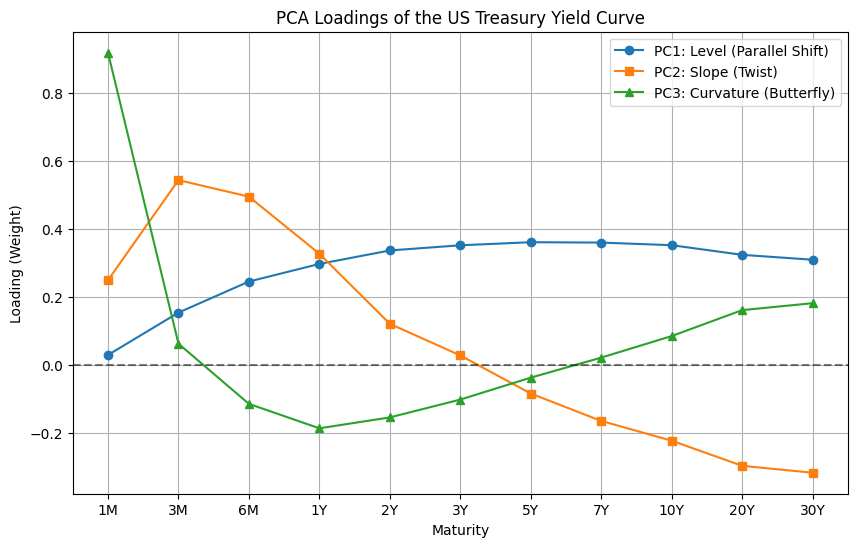

In [6]:
# Extract the loadings (weights) for the first 3 principal components
loadings = pca.components_[:3]

# Create a DataFrame for easy plotting
loadings_df = pd.DataFrame(loadings.T, columns=['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)'], index=labels)

# Plot the Loadings
plt.figure(figsize=(10, 6))
plt.plot(loadings_df['PC1 (Level)'], marker='o', label='PC1: Level (Parallel Shift)')
plt.plot(loadings_df['PC2 (Slope)'], marker='s', label='PC2: Slope (Twist)')
plt.plot(loadings_df['PC3 (Curvature)'], marker='^', label='PC3: Curvature (Butterfly)')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('PCA Loadings of the US Treasury Yield Curve')
plt.xlabel('Maturity')
plt.ylabel('Loading (Weight)')
plt.legend()
plt.grid(True)
plt.show()